In [36]:
# Cell 1: Install Kaggle
!pip install kaggle -q

In [37]:
# Cell 2: Upload Kaggle API key
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vinayakpotty","key":"3bf5f4e1996967641bcb682c6c56426f"}'}

In [38]:
# Cell 3: Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [39]:
# Cell 4: Download FER2013 dataset
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:02<00:00, 31.0MB/s]



In [40]:
# Cell 5: Extract dataset
import zipfile

with zipfile.ZipFile('fer2013.zip','r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [41]:
# Cell 6: Import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import *
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [42]:
# Cell 7: Define dataset paths
train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"

In [43]:
# Cell 8: Create data generators with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48,48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48,48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

print("\nClass indices:", train_generator.class_indices)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.

Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [44]:
# Cell 9: Compute class weights for imbalance
classes = np.unique(train_generator.classes)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [45]:
# Cell 10: Build the model architecture
model = Sequential()

model.add(Input(shape=(48,48,1)))

# Block 1
model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Fully Connected
model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(7,activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,766,343 (10.55 MB)

 Trainable params: 2,764,679 (10.55 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [46]:
# Cell 11: Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
# Cell 12: Setup callbacks
checkpoint = ModelCheckpoint(
    "best_emotion_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [48]:
# Cell 13: Train the model
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=70,
    class_weight=class_weights,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

Epoch 1/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.1644 - loss: 2.6408
Epoch 1: val_accuracy improved from None to 0.19072, saving model to best_emotion_model.keras

Epoch 1: finished saving model to best_emotion_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 43s 74ms/step - accuracy: 0.1771 - loss: 2.3755 - val_accuracy: 0.1907 - val_loss: 2.3407 - learning_rate: 0.0010
Epoch 2/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2309 - loss: 1.9350
Epoch 2: val_accuracy improved from 0.19072 to 0.19184, saving model to best_emotion_model.keras

Epoch 2: finished saving model to best_emotion_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.2463 - loss: 1.8841 - val_accuracy: 0.1918 - val_loss: 2.0320 - learning_rate: 0.0010
Epoch 3/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3121 - loss: 1.7375
Epoch 3: val_accuracy improved from 0.19184 to 0.40763, saving model to best_emotion_model.keras

Epoch 3: finished saving model to best_emoti

In [49]:
# Cell 14: Save the final model
model.save("emotion_model_final.keras")
print("Model saved as emotion_model_final.keras")

Model saved as emotion_model_final.keras


In [50]:
# Cell 15: Evaluate on test set
# Load the best model saved during training
best_model = load_model("best_emotion_model.keras")
loss, acc = best_model.evaluate(test_generator)
print(f"\nTest Accuracy: {acc*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6154 - loss: 1.0364

Test Accuracy: 61.54%
Test Loss: 1.0364


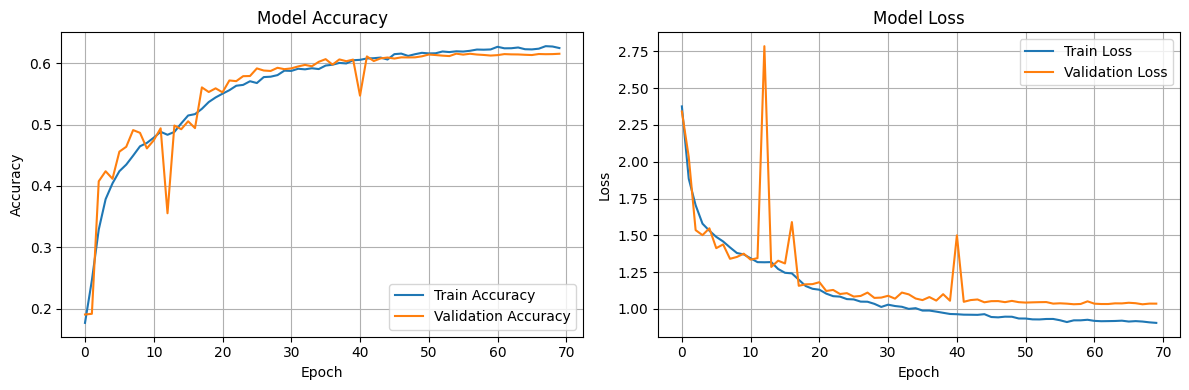

In [51]:
# Cell 16: Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [52]:
# Cell 17: Prediction function for new images
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load the best model
best_model = load_model("best_emotion_model.keras")

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# Face cascade for detection
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def predict_emotion(image_path, show_confidence_details=True):

    # Read image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Cannot load image from {image_path}")
        return None, None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    if len(faces) == 0:
        print("No face detected in the image!")
        print("Try using a clearer image with a visible face.")
        return None, None

    print(f"\nFound {len(faces)} face(s) in the image")

    results = []
    for i, (x, y, w, h) in enumerate(faces):
        # Extract face region
        face = gray[y:y+h, x:x+w]
        face = cv2.resize(face, (48, 48))

        # Normalize and reshape for model
        face_normalized = face / 255.0
        face_input = np.expand_dims(face_normalized, axis=-1)
        face_input = np.expand_dims(face_input, axis=0)

        # Predict
        prediction = best_model.predict(face_input, verbose=0)
        predicted_class = np.argmax(prediction)
        confidence = np.max(prediction) * 100

        predicted_emotion = emotion_labels[predicted_class]

        print(f"\n--- Face {i+1} ---")
        print(f"Location: (x={x}, y={y}, width={w}, height={h})")
        print(f"Predicted Emotion: {predicted_emotion}")
        print(f"Confidence: {confidence:.2f}%")

        if show_confidence_details:
            print("\nConfidence scores for all emotions:")
            for label, score in zip(emotion_labels, prediction[0]):
                print(f"  {label}: {score*100:.2f}%")

        results.append({
            'emotion': predicted_emotion,
            'confidence': confidence,
            'bbox': (x, y, w, h),
            'all_scores': prediction[0]
        })

    return results

def predict_emotion_with_display(image_path):
    """
    Predict emotion and display the image with bounding box and label
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Cannot load image from {image_path}")
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    if len(faces) == 0:
        print("No face detected!")
        return

    for (x, y, w, h) in faces:
        face = gray[y:y+h, x:x+w]
        face = cv2.resize(face, (48, 48))
        face_input = np.expand_dims(face / 255.0, axis=-1)
        face_input = np.expand_dims(face_input, axis=0)

        prediction = best_model.predict(face_input, verbose=0)
        predicted_class = np.argmax(prediction)
        emotion = emotion_labels[predicted_class]
        confidence = np.max(prediction) * 100

        # Draw rectangle and label
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        label = f"{emotion} ({confidence:.1f}%)"
        cv2.putText(img, label, (x, y-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Display the image
    from google.colab.patches import cv2_imshow
    cv2_imshow(img)

Please upload an image file (JPG, PNG, etc.)
The image should contain a clear face for best results.



Saving handsome-man-smiling-happy-face-portrait-close-up.jpg to handsome-man-smiling-happy-face-portrait-close-up.jpg

Processing: handsome-man-smiling-happy-face-portrait-close-up.jpg

Found 1 face(s) in the image

--- Face 1 ---
Location: (x=670, y=514, width=1287, height=1287)
Predicted Emotion: Happy
Confidence: 93.92%

Confidence scores for all emotions:
  Angry: 0.55%
  Disgust: 0.26%
  Fear: 1.13%
  Happy: 93.92%
  Neutral: 1.08%
  Sad: 0.45%
  Surprise: 2.61%


Displaying image with detection:


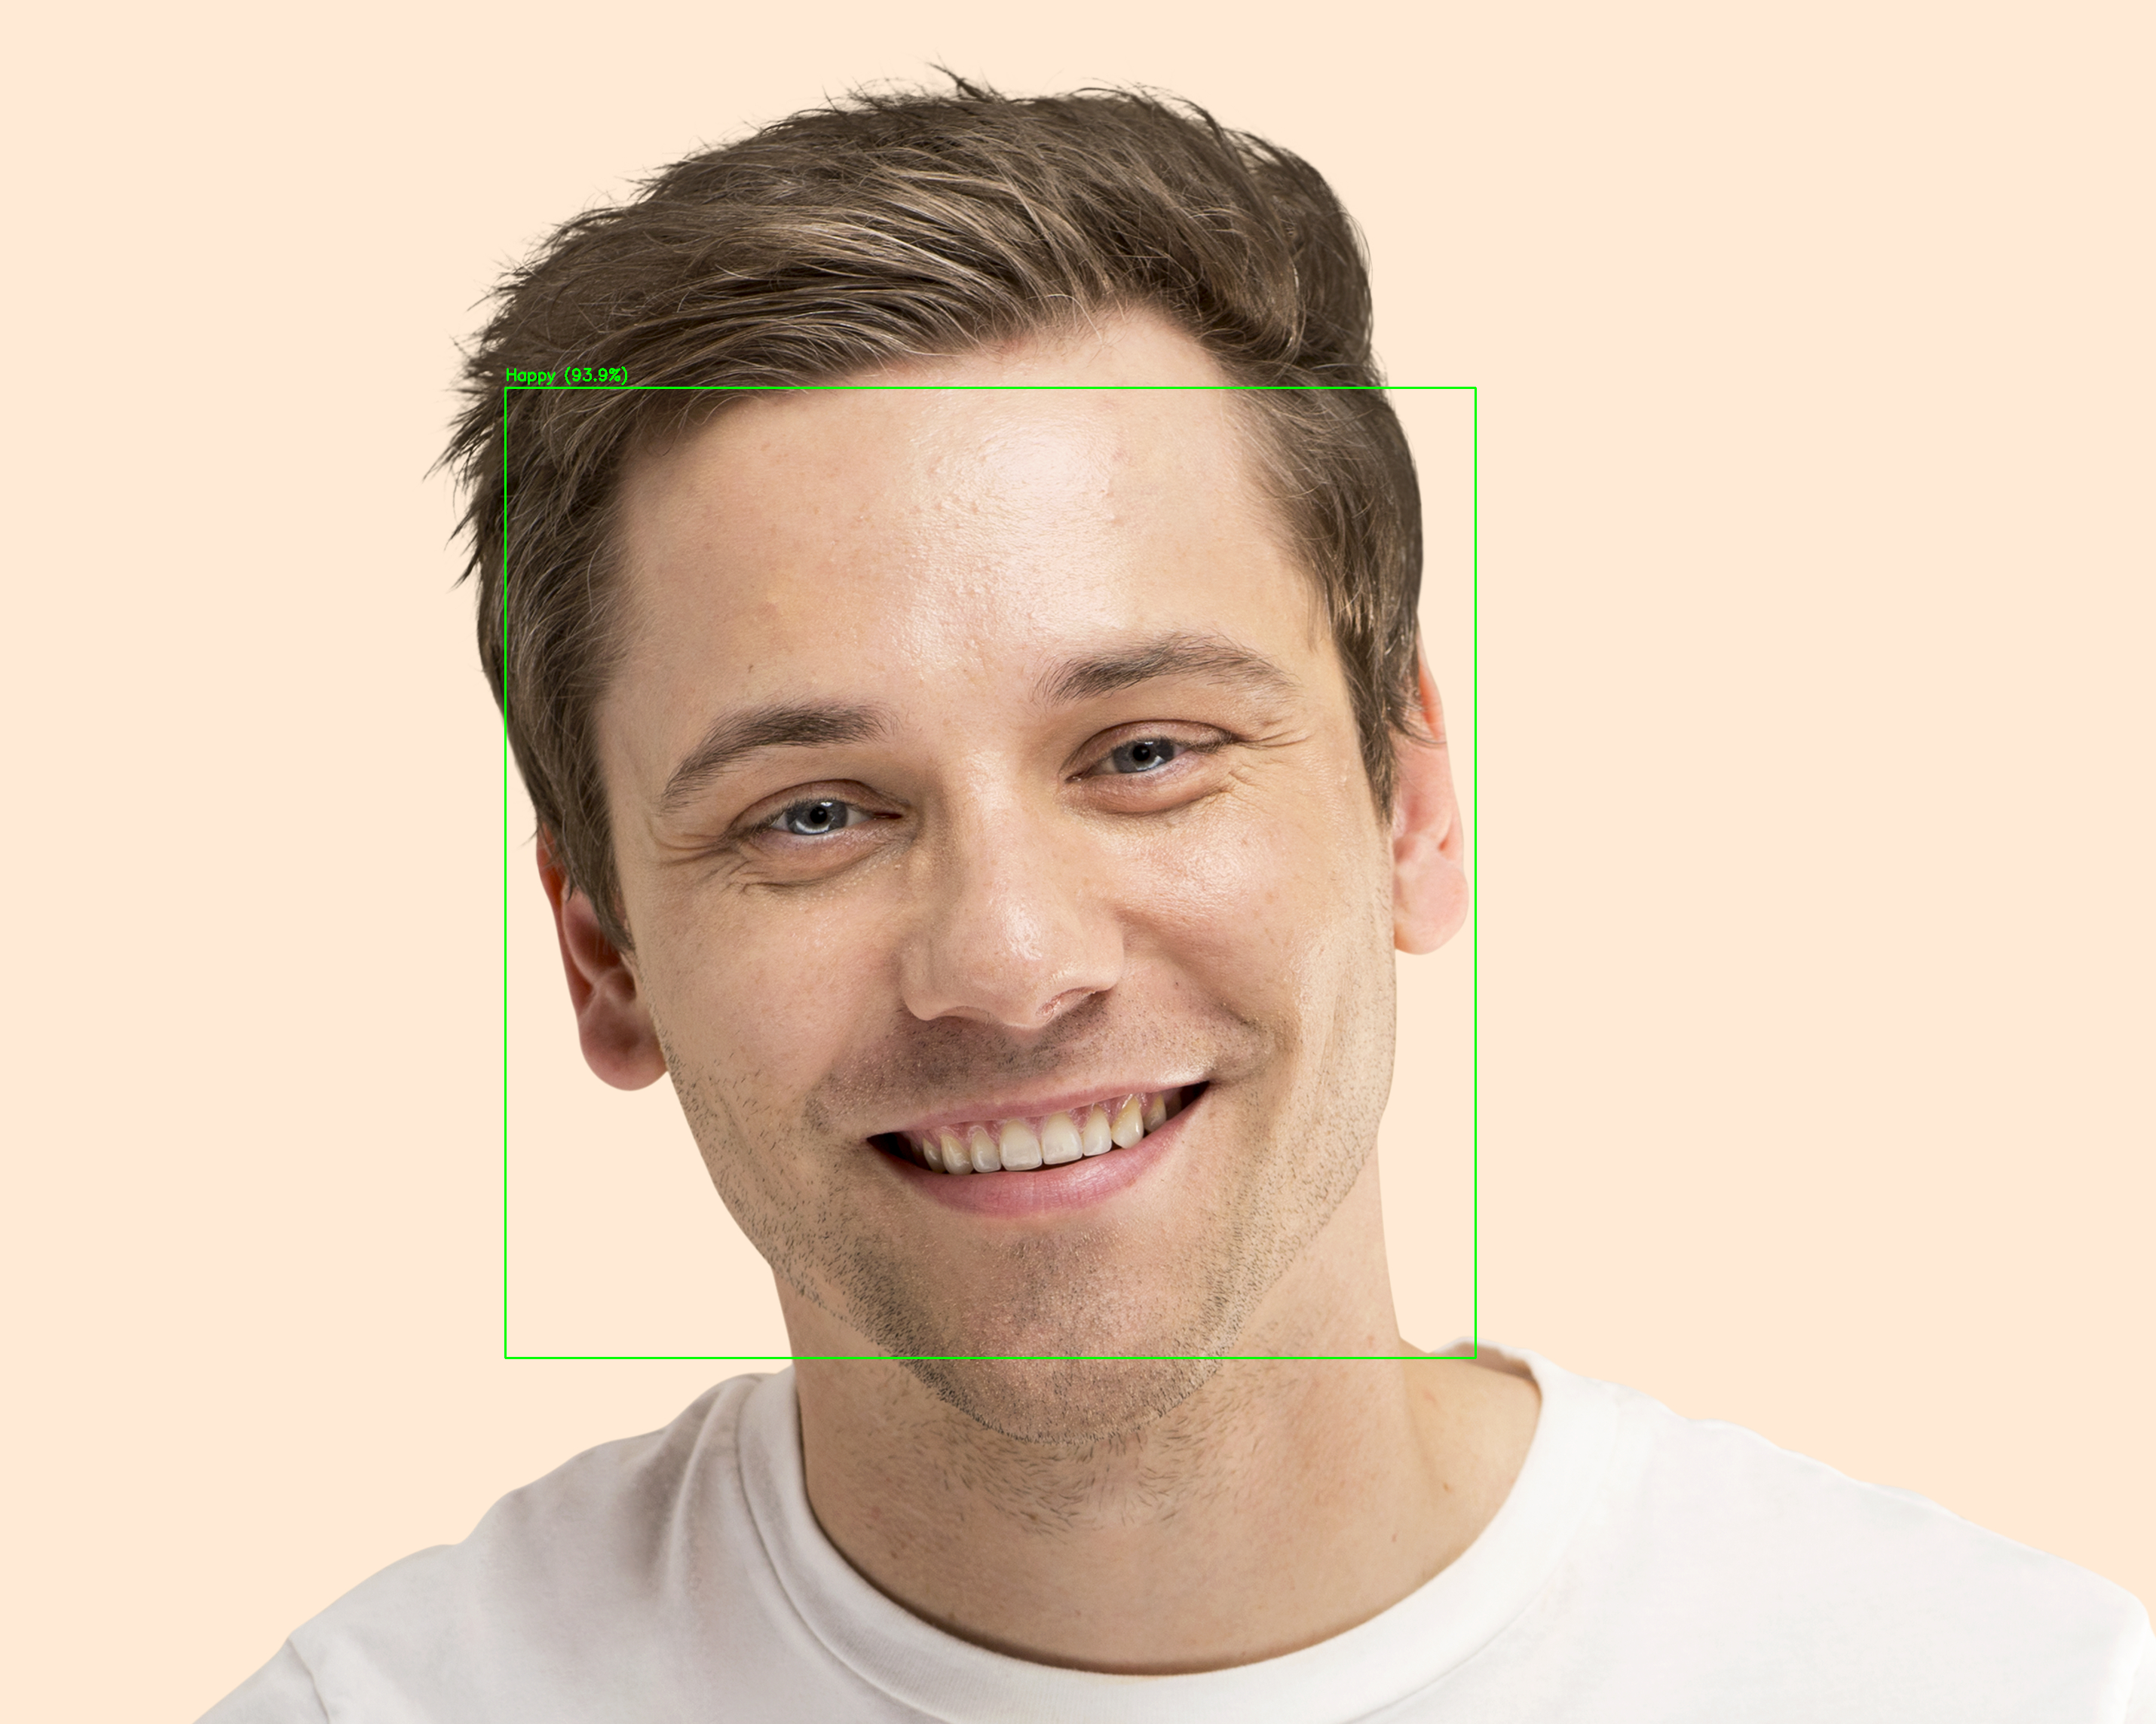

In [54]:
# Cell 18: Upload and test a new image
from google.colab import files

print("Please upload an image file (JPG, PNG, etc.)")
print("The image should contain a clear face for best results.\n")

uploaded = files.upload()

# Process each uploaded file
for filename in uploaded.keys():
    print(f"\n{'='*50}")
    print(f"Processing: {filename}")
    print('='*50)

    # Method 1: Just get prediction
    results = predict_emotion(filename, show_confidence_details=True)

    # Method 2: Display image with bounding box and label
    print("\n\nDisplaying image with detection:")
    predict_emotion_with_display(filename)

In [55]:
# Cell 19: Test on sample images from the dataset (optional)
import random

def test_random_samples(num_samples=5):
    """Test the model on random samples from the test set"""
    class_names = list(train_generator.class_indices.keys())

    # Get all test image paths
    test_images = []
    test_labels = []

    for class_name in class_names:
        class_path = os.path.join(test_dir, class_name)
        if os.path.exists(class_path):
            for img_file in os.listdir(class_path)[:20]:  # Take 20 per class
                if img_file.endswith(('.png', '.jpg', '.jpeg')):
                    test_images.append(os.path.join(class_path, img_file))
                    test_labels.append(class_name)

    # Random selection
    indices = random.sample(range(len(test_images)), min(num_samples, len(test_images)))

    print(f"\nTesting on {len(indices)} random samples from test set:")
    print("="*60)

    for idx in indices:
        img_path = test_images[idx]
        true_label = test_labels[idx]

        # Read and process image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (48, 48))
        img_input = np.expand_dims(img / 255.0, axis=-1)
        img_input = np.expand_dims(img_input, axis=0)

        # Predict
        prediction = best_model.predict(img_input, verbose=0)
        pred_label = emotion_labels[np.argmax(prediction)]
        confidence = np.max(prediction) * 100

        # Check if correct
        is_correct = (pred_label.lower() == true_label.lower())
        status = "✓ CORRECT" if is_correct else "✗ WRONG"

        print(f"\nImage: {os.path.basename(img_path)}")
        print(f"True Label: {true_label}")
        print(f"Predicted: {pred_label} ({confidence:.2f}%)")
        print(f"Status: {status}")

# Run the test (optional - uncomment to run)
# test_random_samples(num_samples=10)

In [56]:
# Cell 20: Save the model for download (optional)
from google.colab import files

# Download the best model to your computer
files.download("best_emotion_model.keras")
print("Model downloaded to your computer!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model downloaded to your computer!
